## Sub-task 2: Stroke Prediction - Supervised Learning

### 1.Exploratory Data Analysis and Data Pre-processing

In [111]:
#import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import itertools
from imblearn.over_sampling import SMOTE, ADASYN
from collections import Counter
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import confusion_matrix

In [2]:
# Load the dataset
df = pd.read_csv('stroke-data.csv')
print(len(df))

5110


In [3]:
df.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


##### 1.1 Group-by counts of stoke risk status

In [4]:
df["stroke"].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

##### 1.2 Analyse and handle missing values 

In [5]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [6]:
missing_summary = df.isnull().sum()
print(missing_summary)

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


##### 1.3 Remove records with missing values 

In [7]:
df_no_null = df.dropna()
print(len(df_no_null))

4909


In [8]:
missing_summary = df_no_null.isnull().sum()
print(missing_summary)

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


##### 1.4 Remove all the duplicate records 

In [9]:
df_no_null_no_duplicate = df_no_null.drop_duplicates()
print(len(df_no_null_no_duplicate))

4909


##### 1.5 Analyse data types for each columns

In [10]:
df_no_null_no_duplicate.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4909 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4909 non-null   int64  
 1   gender             4909 non-null   object 
 2   age                4909 non-null   float64
 3   hypertension       4909 non-null   int64  
 4   heart_disease      4909 non-null   int64  
 5   ever_married       4909 non-null   object 
 6   work_type          4909 non-null   object 
 7   Residence_type     4909 non-null   object 
 8   avg_glucose_level  4909 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     4909 non-null   object 
 11  stroke             4909 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 498.6+ KB


##### 1.6  Outliers detection and removal

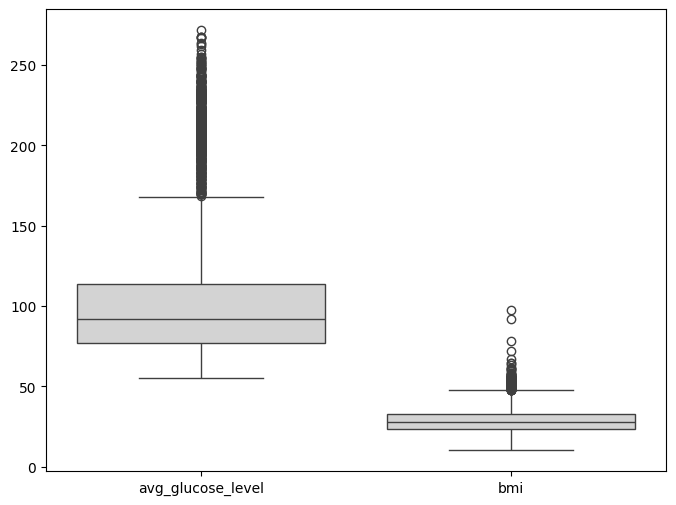

In [11]:
# Create the box plot
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_no_null_no_duplicate[['avg_glucose_level', 'bmi']], color='lightgray')

# Show the plot
plt.show()

In [12]:
# Calculate IQR
Q1 = df_no_null_no_duplicate[['avg_glucose_level', 'bmi']].quantile(0.25)
Q3 = df_no_null_no_duplicate[['avg_glucose_level', 'bmi']].quantile(0.75)
IQR = Q3 - Q1

# Define the filter for non-outlier rows
filter_no_outliers = ~(
    (df_no_null_no_duplicate[['avg_glucose_level', 'bmi']] < (Q1 - 1.5 * IQR)) |
    (df_no_null_no_duplicate[['avg_glucose_level', 'bmi']] > (Q3 + 1.5 * IQR))
).any(axis=1)

# Apply the filter to keep only non-outlier rows
df_no_null_no_duplicate_no_outliers = df_no_null_no_duplicate[filter_no_outliers]
len(df_no_null_no_duplicate_no_outliers)

4260

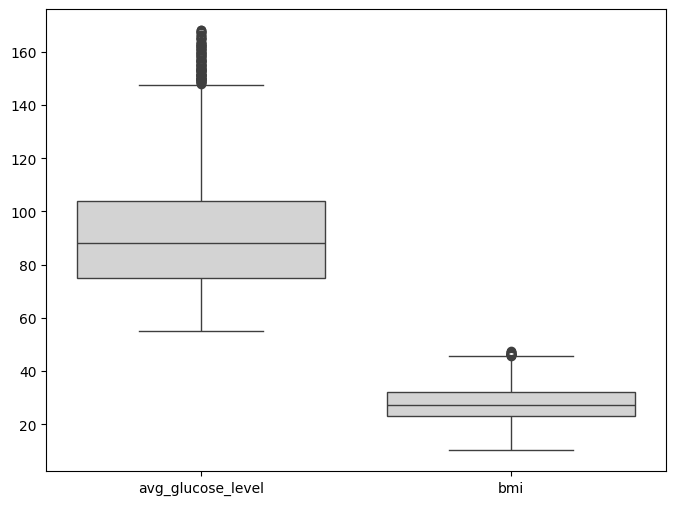

In [13]:
# Create the box plot
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_no_null_no_duplicate_no_outliers[['avg_glucose_level', 'bmi']], color='lightgray')

# Show the plot
plt.show()

##### 1.7 Selected feature variables

Article 1 from the medical team emphasizes that the following features are related to the risk of stroke.

| Feature Variable Name | Relevance to Stroke Risk | Justification from Reference |
| :------------------- | :---------------------- | :---------------------------- |
| gender | Relevant | "Being male" increases stroke risk. |
| age | Relevant | "Being older" increases stroke risk. |
| hypertension | Relevant | "Blood pressure" (hypertension) is a major risk factor for stroke. |
| heart_disease | Relevant | "Heart health" and "irregular pulse" problems increase stroke risk. |
| ever_married | Not Directly Relevant | No direct mention about marital status affecting stroke risk. |
| work_type | Possibly Indirectly Relevant | Occupation might relate to lifestyle factors ("Be active"). |
| Residence_type | Not Directly Relevant | No direct link about residence type and stroke risk. |
| avg_glucose_level | Relevant | High blood sugar is a known stroke risk factor. |
| bmi | Relevant | "Be a healthy weight" — unhealthy BMI increases stroke risk. |
| smoking_status | Relevant | "Don't smoke" — smoking is a significant risk factor for stroke. |


In [36]:
df_features = df_no_null_no_duplicate_no_outliers[['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status']]
df_target = df_no_null_no_duplicate_no_outliers[['stroke']]

In [37]:
df_features.shape

(4260, 10)

In [38]:
df_target.shape

(4260, 1)

In [39]:
df_features.head(10)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked
6,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked
7,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked
9,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown
10,Female,81.0,1,0,Yes,Private,Rural,80.43,29.7,never smoked
11,Female,61.0,0,1,Yes,Govt_job,Rural,120.46,36.8,smokes
12,Female,54.0,0,0,Yes,Private,Urban,104.51,27.3,smokes
15,Female,50.0,1,0,Yes,Self-employed,Rural,167.41,30.9,never smoked
18,Female,60.0,0,0,No,Private,Urban,89.22,37.8,never smoked
24,Male,71.0,0,0,Yes,Private,Urban,102.87,27.2,formerly smoked


In [40]:
df_target.head(10)

,stroke
2,1
6,1
7,1
9,1
10,1
11,1
12,1
15,1
18,1
24,1


##### 1.8 Convert numerical type into categorical one

Based on the Article 3, we can convert Avg_glucose_level into a categorical variable by following the glucose categories used in the study.

| Glucose Range (mg/dL) | Category Name            |
|----------------------|------------------------|
| < 70                  | Very Low                |
| 70–84                 | Low                     |
| 85–99                 | Normal (reference)      |
| 100–109               | Impaired Fasting (mild) |
| 110–125               | Impaired Fasting        |
| 126–139               | Diabetes (mild)         |
| ≥ 140                 | Diabetes (high)         |

In [41]:
# Function to assign group
def categorize_glucose(avg_glucose_level):
    if avg_glucose_level < 70:
        return 'Very Low'
    elif 70 <= avg_glucose_level <= 84:
        return 'Low'
    elif 85 <= avg_glucose_level <= 99:
        return 'Normal'
    elif 100 <= avg_glucose_level <= 109:
        return 'Impaired Fasting (mild)'
    elif 110 <= avg_glucose_level <= 125:
        return 'Impaired Fasting'
    elif 126 <= avg_glucose_level <= 139:
        return 'Diabetes (mild)'
    else:  # >= 140
        return 'Diabetes (high)'
    
# Apply the function
Avg_glucose_level_group_col = df_features['avg_glucose_level'].apply(categorize_glucose)
Avg_glucose_level_col_index = df_features.columns.get_loc('avg_glucose_level')
df_features.insert(Avg_glucose_level_col_index, 'avg_glucose_level_group', Avg_glucose_level_group_col)
df_features = df_features.drop(columns=['avg_glucose_level'])

Based on the Article 4, BMI value convert from a numerical BMI value into categorical values:

| **BMI Range (kg/m²)**      | **BMI Category**          |
|---------------------------|--------------------------|
| < 18.5                     | Underweight              |
| 18.5 – < 25                | Healthy Weight           |
| 25 – < 30                  | Overweight               |
| 30 – < 35                  | Obesity Class 1          |
| 35 – < 40                  | Obesity Class 2          |
| ≥ 40                       | Obesity Class 3 (Severe) |

In [42]:
# Function to assign group
def categorize_bmi(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif 18.5 <= bmi < 25:
        return 'Healthy Weight'
    elif 25 <= bmi < 30:
        return 'Overweight'
    elif 30 <= bmi < 35:
        return 'Obesity Class 1'
    elif 35 <= bmi < 40:
        return 'Obesity Class 2'
    else:  # bmi >= 40
        return 'Obesity Class 3 (Severe)'

# Apply the function
bmi_group_col = df_features['bmi'].apply(categorize_bmi)
bmi_col_index = df_features.columns.get_loc('bmi')
df_features.insert(bmi_col_index, 'bmi_group', bmi_group_col)
df_features = df_features.drop(columns=['bmi'])



Based on the reference paper, divide all patients into three age groups according their ages at onset: (1) young adult group (<50 years); (2) middle-aged group (50~80 years); (3) very old group (>80 years).

In [43]:
# Function to assign age group
def assign_age_group(age):
    if age < 50:
        return 'Young Adult'
    elif 50 <= age <= 80:
        return 'Middle-Aged'
    else:
        return 'Very Old'
    
# Apply the function
age_group_col = df_features['age'].apply(assign_age_group)
age_col_index = df_features.columns.get_loc('age')
df_features.insert(age_col_index, 'age_group', age_group_col)
df_features = df_features.drop(columns=['age'])

In [44]:
df_features.head(10)

,gender,age_group,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level_group,bmi_group,smoking_status
2,Male,Middle-Aged,0,1,Yes,Private,Rural,Impaired Fasting (mild),Obesity Class 1,never smoked
6,Male,Middle-Aged,1,1,Yes,Private,Rural,Low,Overweight,never smoked
7,Female,Middle-Aged,0,0,No,Private,Urban,Normal,Healthy Weight,never smoked
9,Female,Middle-Aged,0,0,Yes,Private,Urban,Very Low,Healthy Weight,Unknown
10,Female,Very Old,1,0,Yes,Private,Rural,Low,Overweight,never smoked
11,Female,Middle-Aged,0,1,Yes,Govt_job,Rural,Impaired Fasting,Obesity Class 2,smokes
12,Female,Middle-Aged,0,0,Yes,Private,Urban,Impaired Fasting (mild),Overweight,smokes
15,Female,Middle-Aged,1,0,Yes,Self-employed,Rural,Diabetes (high),Obesity Class 1,never smoked
18,Female,Middle-Aged,0,0,No,Private,Urban,Normal,Obesity Class 2,never smoked
24,Male,Middle-Aged,0,0,Yes,Private,Urban,Impaired Fasting (mild),Overweight,formerly smoked


In [45]:
df_features.shape

(4260, 10)

##### 1.9  Apply encoding for catagorical variables

In [ ]:
# Binary encoding for married status
binary_mapping = {     
    'ever_married': {'Yes': 1, 'No': 0}
}

for column, mapping in binary_mapping.items():
    df_features[column] = df_features[column].map(mapping)

In [ ]:
# Onehot encoding 
categorical_columns = ['gender','age_group', 'work_type', 'Residence_type', 'avg_glucose_level_group', 'bmi_group', 'smoking_status']
numerical_columns = ['hypertension', 'heart_disease', 'ever_married']

preprocessor = ColumnTransformer(
    transformers=[
        # Drop the first category to avoid multicollinearity (dummy variable trap)
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_columns),
        ('num', 'passthrough', numerical_columns)
    ])

X_transformed = preprocessor.fit_transform(df_features)
X_transformed = X_transformed.toarray()

df_features = pd.DataFrame(
    X_transformed,
    columns= preprocessor.get_feature_names_out()
)

In [54]:
df_features.shape

(4260, 26)

In [53]:
df_features.head(10)

,cat__gender_Male,cat__gender_Other,cat__age_group_Very Old,cat__age_group_Young Adult,cat__work_type_Never_worked,cat__work_type_Private,cat__work_type_Self-employed,cat__work_type_children,cat__Residence_type_Urban,cat__avg_glucose_level_group_Diabetes (mild),...,cat__bmi_group_Obesity Class 2,cat__bmi_group_Obesity Class 3 (Severe),cat__bmi_group_Overweight,cat__bmi_group_Underweight,cat__smoking_status_formerly smoked,cat__smoking_status_never smoked,cat__smoking_status_smokes,num__hypertension,num__heart_disease,num__ever_married
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
6,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
7,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
8,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
9,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [52]:
df_features.iloc[:,9:15].head(10)

,cat__avg_glucose_level_group_Diabetes (mild),cat__avg_glucose_level_group_Impaired Fasting,cat__avg_glucose_level_group_Impaired Fasting (mild),cat__avg_glucose_level_group_Low,cat__avg_glucose_level_group_Normal,cat__avg_glucose_level_group_Very Low
0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,1.0,0.0,0.0
5,0.0,1.0,0.0,0.0,0.0,0.0
6,0.0,0.0,1.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,1.0,0.0
9,0.0,0.0,1.0,0.0,0.0,0.0


In [57]:
df_features.iloc[:,15:20].head(10)

,cat__bmi_group_Obesity Class 1,cat__bmi_group_Obesity Class 2,cat__bmi_group_Obesity Class 3 (Severe),cat__bmi_group_Overweight,cat__bmi_group_Underweight
0,1.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0
5,0.0,1.0,0.0,0.0,0.0
6,0.0,0.0,0.0,1.0,0.0
7,1.0,0.0,0.0,0.0,0.0
8,0.0,1.0,0.0,0.0,0.0
9,0.0,0.0,0.0,1.0,0.0


##### 1.10 Correlation coefficients between pairs of features, aiding in the detection of highly correlated attributes

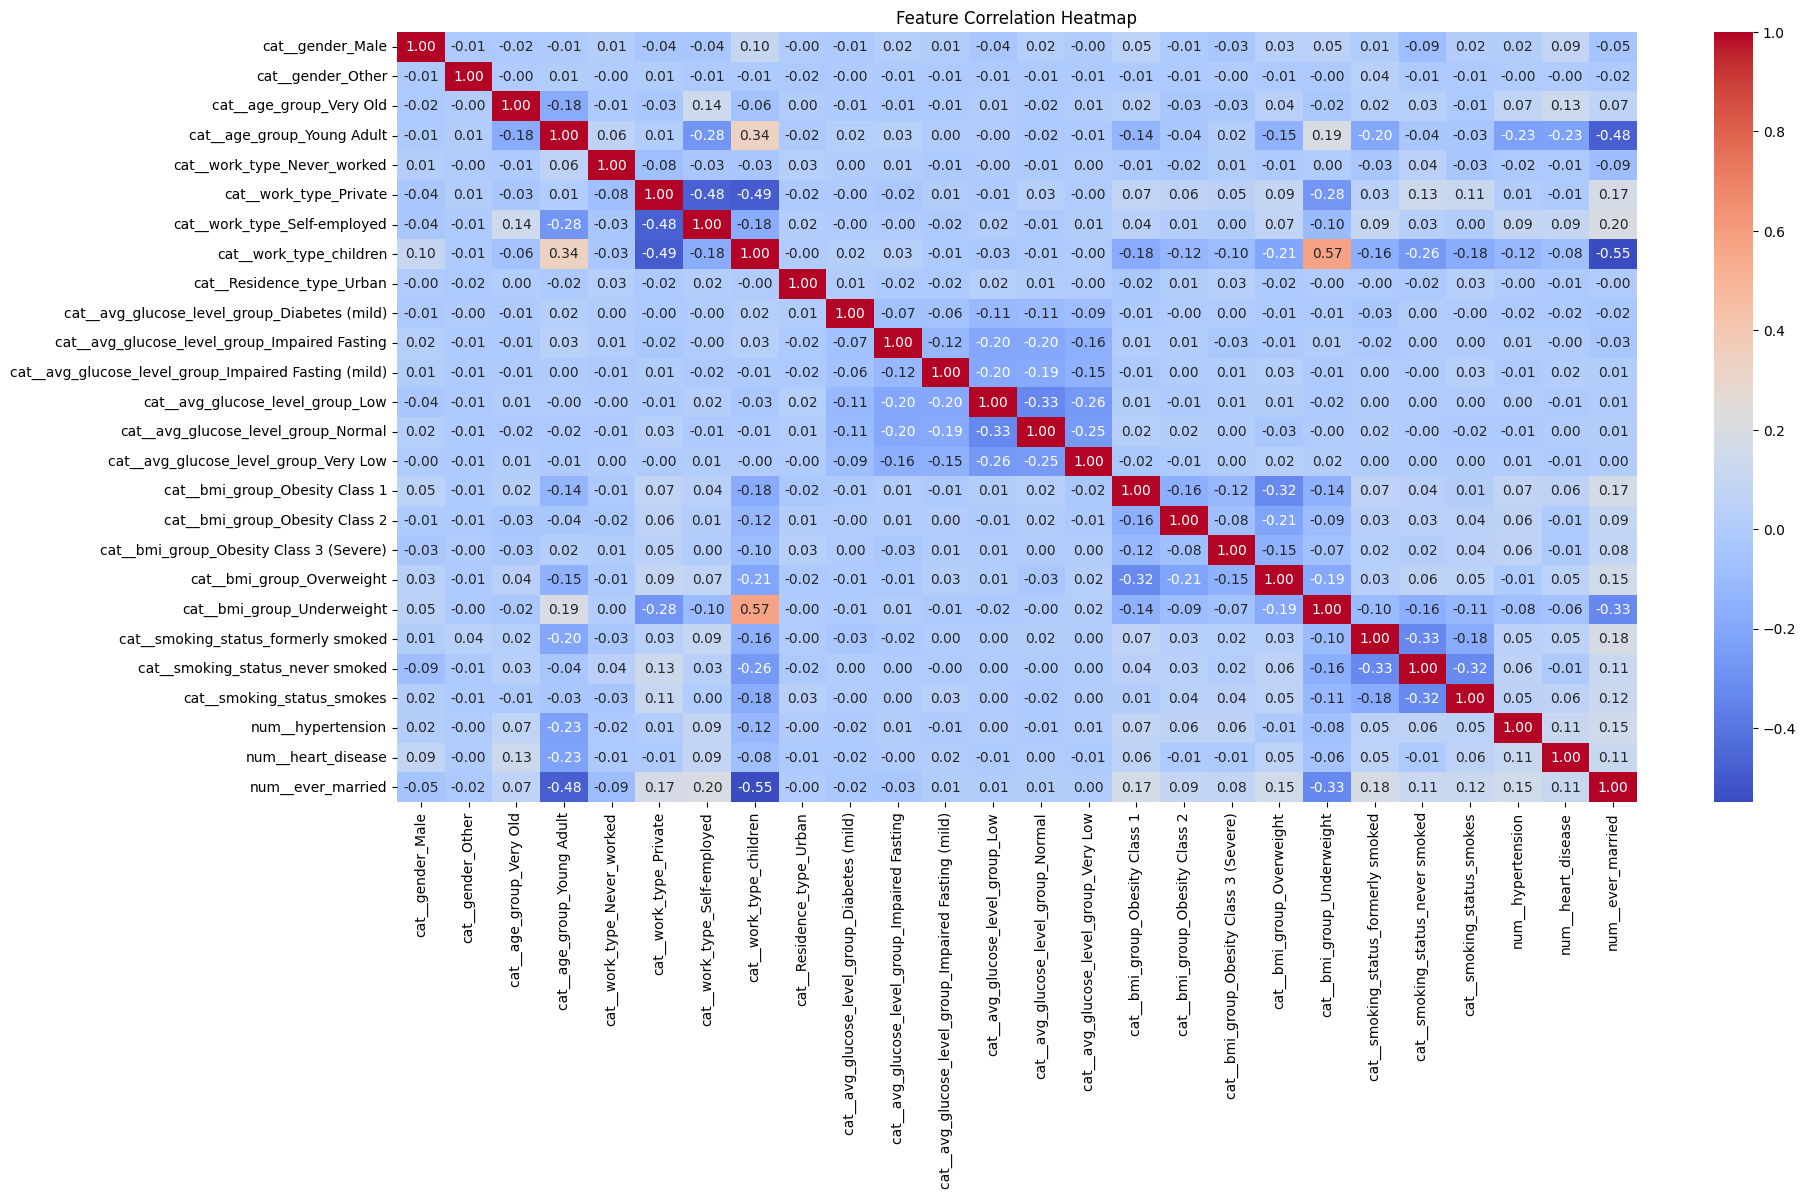

In [62]:
corr = df_features.corr()
plt.figure(figsize=(20, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

Gained insights:

There are notable variables highly correlated to each others. 
Eg : bmi_group_underweight & never_married (-0.33), bmi_group_underweight & work_type_children (0.57)

##### 1.11 Merge target column with feature variables

In [63]:
# Combine df_target with df_features
df_features = df_features.reset_index(drop=True)
df_target = df_target.reset_index(drop=True)
df_merged = pd.concat([df_features, df_target], axis=1)

In [64]:
df_merged.shape

(4260, 27)

In [65]:
df_merged.head(10)

,cat__gender_Male,cat__gender_Other,cat__age_group_Very Old,cat__age_group_Young Adult,cat__work_type_Never_worked,cat__work_type_Private,cat__work_type_Self-employed,cat__work_type_children,cat__Residence_type_Urban,cat__avg_glucose_level_group_Diabetes (mild),...,cat__bmi_group_Obesity Class 3 (Severe),cat__bmi_group_Overweight,cat__bmi_group_Underweight,cat__smoking_status_formerly smoked,cat__smoking_status_never smoked,cat__smoking_status_smokes,num__hypertension,num__heart_disease,num__ever_married,stroke
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1
6,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1
7,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1
8,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1
9,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1


## 2.Data Modeling and Feature Engineering

##### 2.1 Data imbalance check

In [67]:
df_merged['stroke'].value_counts()

stroke
0    4124
1     136
Name: count, dtype: int64

Gained insights :
Since the given dataset is imbalanced, "balanced accuray" is used to evaluate and compare the models performance. 

##### 2.2 Build the base-line model (LogisticRegression)

In [ ]:
# Split features and target
X, y = np.array(df_merged.iloc[:, :-1]) , np.array(df_merged.iloc[:,-1])

# Initialize model
logreg = LogisticRegression(max_iter=1000)

# Initialize StratifiedKFold
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

balanced_acc_scores = []
fold = 1

for train_idx, val_idx in kfold.split(X, y):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    
    # Train
    logreg.fit(X_train, y_train)
    
    # Predict
    y_pred = logreg.predict(X_val)
    
    # Evaluate
    balanced_acc = balanced_accuracy_score(y_val, y_pred)
    balanced_acc_scores.append(balanced_acc)
    
    print(f"\nFold {fold} Balanced Accuracy: {balanced_acc:.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
    
    fold += 1

# Overall results
print("\nAverage Balanced Accuracy:", np.mean(balanced_acc_scores))


Fold 1 Balanced Accuracy: 0.5000
Confusion Matrix:
 [[824   0]
 [ 28   0]]

Fold 2 Balanced Accuracy: 0.5000
Confusion Matrix:
 [[825   0]
 [ 27   0]]

Fold 3 Balanced Accuracy: 0.4994
Confusion Matrix:
 [[824   1]
 [ 27   0]]

Fold 4 Balanced Accuracy: 0.5000
Confusion Matrix:
 [[825   0]
 [ 27   0]]

Fold 5 Balanced Accuracy: 0.5000
Confusion Matrix:
 [[825   0]
 [ 27   0]]

Average Balanced Accuracy: 0.4998787878787879


##### 2.3 Implement feature scaling : standard scaler 

In [76]:
# Split features and target
X, y = np.array(df_merged.iloc[:, :-1]) , np.array(df_merged.iloc[:,-1])

#scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Initialize model
logreg = LogisticRegression(max_iter=1000)

# Initialize StratifiedKFold
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

balanced_acc_scores = []
fold = 1

for train_idx, val_idx in kfold.split(X, y):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    
    # Train
    logreg.fit(X_train, y_train)
    
    # Predict
    y_pred = logreg.predict(X_val)
    
    # Evaluate
    balanced_acc = balanced_accuracy_score(y_val, y_pred)
    balanced_acc_scores.append(balanced_acc)
    
    print(f"\nFold {fold} Balanced Accuracy: {balanced_acc:.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
    
    fold += 1

# Overall results
print("\nAverage Balanced Accuracy:", np.mean(balanced_acc_scores))


Fold 1 Balanced Accuracy: 0.5000
Confusion Matrix:
 [[824   0]
 [ 28   0]]

Fold 2 Balanced Accuracy: 0.5000
Confusion Matrix:
 [[825   0]
 [ 27   0]]

Fold 3 Balanced Accuracy: 0.4994
Confusion Matrix:
 [[824   1]
 [ 27   0]]

Fold 4 Balanced Accuracy: 0.5000
Confusion Matrix:
 [[825   0]
 [ 27   0]]

Fold 5 Balanced Accuracy: 0.5000
Confusion Matrix:
 [[825   0]
 [ 27   0]]

Average Balanced Accuracy: 0.4998787878787879


Gained insights :
There is no improvement obtained by scaling the features , since all the values are aready in same scale (0-1).

##### 2.4 Build the Bagging model (Radom forest) 

In [99]:
# Split features and target
X, y = np.array(df_merged.iloc[:, :-1]) , np.array(df_merged.iloc[:,-1])

# Initialize Random Forest with class_weight='balanced'
rf_model = RandomForestClassifier(
    n_estimators=5,
    random_state=42,
    class_weight='balanced'  # Handles the imbalance automatically
)

# Initialize StratifiedKFold
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

balanced_acc_scores = []
fold = 1

for train_idx, val_idx in kfold.split(X, y):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    
    # Train
    rf_model.fit(X_train, y_train)
    
    # Predict
    y_pred = rf_model.predict(X_val)
    
    # Evaluate
    balanced_acc = balanced_accuracy_score(y_val, y_pred)
    balanced_acc_scores.append(balanced_acc)
    
    print(f"\nFold {fold} Balanced Accuracy: {balanced_acc:.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
    
    fold += 1

# Overall results
print("\nAverage Balanced Accuracy:", np.mean(balanced_acc_scores))


Fold 1 Balanced Accuracy: 0.5329
Confusion Matrix:
 [[790  34]
 [ 25   3]]

Fold 2 Balanced Accuracy: 0.4855
Confusion Matrix:
 [[801  24]
 [ 27   0]]

Fold 3 Balanced Accuracy: 0.5434
Confusion Matrix:
 [[805  20]
 [ 24   3]]

Fold 4 Balanced Accuracy: 0.5286
Confusion Matrix:
 [[811  14]
 [ 25   2]]

Fold 5 Balanced Accuracy: 0.4891
Confusion Matrix:
 [[807  18]
 [ 27   0]]

Average Balanced Accuracy: 0.51589446942845


Gained insights :
There is slight improvement obtained by bagging model.

## 3.Features reduction and extraction - Principle Component Analysis (PCA)

##### 3.1 Explained Variance plot 

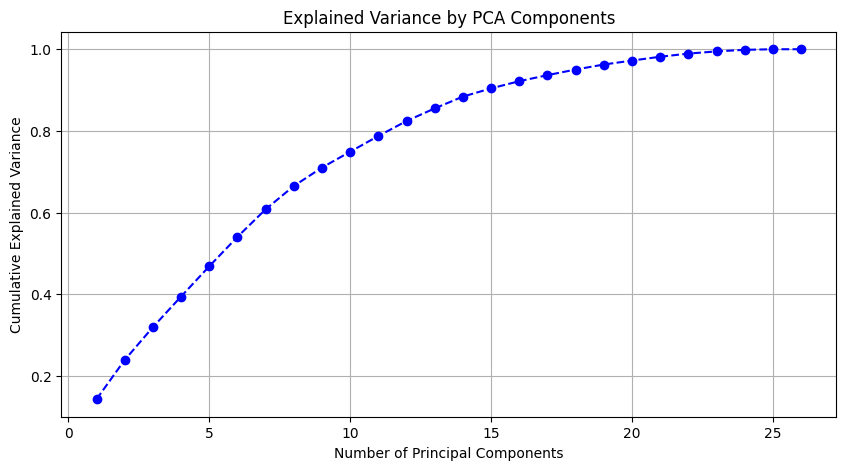

In [100]:
# Fit PCA with all components
pca = PCA(n_components=None)
pca.fit(X)

# Explained variance ratio
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o', linestyle='--', color='b')
plt.title('Explained Variance by PCA Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

#### 3.2 Apply hyper parameter tuning for number of estimators and number of principle components

In [104]:
# Define parameter ranges
n_components_list = [5, 8, 10, 12, 15, 20]
n_estimators_list = [5, 10, 20]

best_score = 0
best_params = {}
results = []

for n_components, n_estimators in itertools.product(n_components_list, n_estimators_list):
    # Apply PCA
    pca = PCA(n_components=n_components)
    # Initialize StratifiedKFold
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    balanced_acc_scores = []

    for train_idx, val_idx in kfold.split(X, y):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        principal_components_train = pca.fit_transform(X_train)
        principal_components_val = pca.transform(X_val)
        
        # Train
        rf_pca = RandomForestClassifier(n_estimators=n_estimators, class_weight='balanced', random_state=42)
        rf_pca.fit(principal_components_train, y_train)
        
        # Predict
        y_pred = rf_pca.predict(principal_components_val)
        
        # Evaluate
        balanced_acc = balanced_accuracy_score(y_val, y_pred)
        balanced_acc_scores.append(balanced_acc)
    
    if np.mean(balanced_acc_scores) > best_score:
        best_score = np.mean(balanced_acc_scores)
        best_params = {
            'n_components': n_components,
            'n_estimators': n_estimators
        }
 
# Print best results
print("Best Balanced Accuracy Score:", best_score)
print("Best Parameters:", best_params)

Best Balanced Accuracy Score: 0.515221362959227
Best Parameters: {'n_components': 8, 'n_estimators': 20}


#### 3.3 Obtain the confusion matrix for the optimal model

In [105]:
# Initialize Random Forest with class_weight='balanced'
rf_model_optimal  = RandomForestClassifier(
    n_estimators=20,
    random_state=42,
    class_weight='balanced'  # Handles the imbalance automatically
)

# Initialize StratifiedKFold
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pca_optimal = PCA(n_components=8)

balanced_acc_scores = []
fold = 1

for train_idx, val_idx in kfold.split(X, y):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    principal_components_train_opt = pca_optimal.fit_transform(X_train)
    principal_components_val_opt = pca_optimal.transform(X_val)
    
    # Train
    rf_model_optimal.fit(principal_components_train_opt, y_train)
    
    # Predict
    y_pred = rf_model_optimal.predict(principal_components_val_opt)
    
    # Evaluate
    balanced_acc = balanced_accuracy_score(y_val, y_pred)
    balanced_acc_scores.append(balanced_acc)
    
    print(f"\nFold {fold} Balanced Accuracy: {balanced_acc:.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
    
    fold += 1

# Overall results
print("\nAverage Balanced Accuracy:", np.mean(balanced_acc_scores))


Fold 1 Balanced Accuracy: 0.5342
Confusion Matrix:
 [[792  32]
 [ 25   3]]

Fold 2 Balanced Accuracy: 0.4885
Confusion Matrix:
 [[806  19]
 [ 27   0]]

Fold 3 Balanced Accuracy: 0.5298
Confusion Matrix:
 [[813  12]
 [ 25   2]]

Fold 4 Balanced Accuracy: 0.5340
Confusion Matrix:
 [[820   5]
 [ 25   2]]

Fold 5 Balanced Accuracy: 0.4897
Confusion Matrix:
 [[808  17]
 [ 27   0]]

Average Balanced Accuracy: 0.515221362959227


## 4.Addressing class imbalance - SMOTE

In [106]:
# Initialize Random Forest 
rf_model_smote  = RandomForestClassifier(
    n_estimators=20,
    random_state=42,
)

# Initialize StratifiedKFold
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

balanced_acc_scores = []
fold = 1

for train_idx, val_idx in kfold.split(X, y):
    
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    print("Original class distribution:", Counter(y_train))

    # SMOTE
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
    print("After SMOTE:", Counter(y_train_smote))

    # Train
    rf_model_smote.fit(X_train_smote, y_train_smote)
    
    # Predict
    y_pred = rf_model_smote.predict(X_val)
    
    # Evaluate
    balanced_acc = balanced_accuracy_score(y_val, y_pred)
    balanced_acc_scores.append(balanced_acc)
    
    print(f"\nFold {fold} Balanced Accuracy: {balanced_acc:.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
    
    fold += 1

# Overall results
print("\nAverage Balanced Accuracy:", np.mean(balanced_acc_scores))

Original class distribution: Counter({0: 3300, 1: 108})
After SMOTE: Counter({1: 3300, 0: 3300})

Fold 1 Balanced Accuracy: 0.5303
Confusion Matrix:
 [[815   9]
 [ 26   2]]
Original class distribution: Counter({0: 3299, 1: 109})
After SMOTE: Counter({1: 3299, 0: 3299})

Fold 2 Balanced Accuracy: 0.4982
Confusion Matrix:
 [[822   3]
 [ 27   0]]
Original class distribution: Counter({0: 3299, 1: 109})
After SMOTE: Counter({1: 3299, 0: 3299})

Fold 3 Balanced Accuracy: 0.5143
Confusion Matrix:
 [[818   7]
 [ 26   1]]
Original class distribution: Counter({0: 3299, 1: 109})
After SMOTE: Counter({1: 3299, 0: 3299})

Fold 4 Balanced Accuracy: 0.5149
Confusion Matrix:
 [[819   6]
 [ 26   1]]
Original class distribution: Counter({0: 3299, 1: 109})
After SMOTE: Counter({1: 3299, 0: 3299})

Fold 5 Balanced Accuracy: 0.4952
Confusion Matrix:
 [[817   8]
 [ 27   0]]

Average Balanced Accuracy: 0.5105489406314649


#### 4.1 Apply both SMOTE + PCA

In [107]:
# Initialize Random Forest 
rf_model_smote_pca  = RandomForestClassifier(
    n_estimators=5,
    random_state=42,
)

# Initialize StratifiedKFold
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

balanced_acc_scores = []
fold = 1

for train_idx, val_idx in kfold.split(X, y):
    
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    print("Original class distribution:", Counter(y_train))

    # SMOTE
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
    print("After SMOTE:", Counter(y_train_smote))

    principal_components_train_opt_smote = pca_optimal.fit_transform(X_train_smote)
    principal_components_val_opt_smote = pca_optimal.transform(X_val)
    
    # Train
    rf_model_smote.fit(principal_components_train_opt_smote, y_train_smote)
    
    # Predict
    y_pred = rf_model_smote.predict(principal_components_val_opt_smote)
    
    # Evaluate
    balanced_acc = balanced_accuracy_score(y_val, y_pred)
    balanced_acc_scores.append(balanced_acc)
    
    print(f"\nFold {fold} Balanced Accuracy: {balanced_acc:.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
     
    fold += 1

# Overall results
print("\nAverage Balanced Accuracy:", np.mean(balanced_acc_scores))

Original class distribution: Counter({0: 3300, 1: 108})
After SMOTE: Counter({1: 3300, 0: 3300})

Fold 1 Balanced Accuracy: 0.5959
Confusion Matrix:
 [[776  48]
 [ 21   7]]
Original class distribution: Counter({0: 3299, 1: 109})
After SMOTE: Counter({1: 3299, 0: 3299})

Fold 2 Balanced Accuracy: 0.5313
Confusion Matrix:
 [[785  40]
 [ 24   3]]
Original class distribution: Counter({0: 3299, 1: 109})
After SMOTE: Counter({1: 3299, 0: 3299})

Fold 3 Balanced Accuracy: 0.5738
Confusion Matrix:
 [[794  31]
 [ 22   5]]
Original class distribution: Counter({0: 3299, 1: 109})
After SMOTE: Counter({1: 3299, 0: 3299})

Fold 4 Balanced Accuracy: 0.5307
Confusion Matrix:
 [[784  41]
 [ 24   3]]
Original class distribution: Counter({0: 3299, 1: 109})
After SMOTE: Counter({1: 3299, 0: 3299})

Fold 5 Balanced Accuracy: 0.5222
Confusion Matrix:
 [[770  55]
 [ 24   3]]

Average Balanced Accuracy: 0.550784184890981


#### 4.2 Apply hyper parameter tuning for number of estimators and number of principle components - SMOTE + PCA

In [109]:
# Define parameter ranges
n_components_list = [5, 8, 10, 12, 15, 20]
n_estimators_list = [5, 10, 20]

best_score = 0
best_params = {}
results = []

for n_components, n_estimators in itertools.product(n_components_list, n_estimators_list):
    # Apply PCA
    pca = PCA(n_components=n_components)
    # Initialize StratifiedKFold
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    balanced_acc_scores = []

    for train_idx, val_idx in kfold.split(X, y):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        # SMOTE
        smote = SMOTE(random_state=42)
        X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

        principal_components_train_smote = pca.fit_transform(X_train_smote)
        principal_components_val_smote = pca.transform(X_val)
        
        # Train
        rf_pca_smote = RandomForestClassifier(n_estimators=n_estimators, random_state=42)
        rf_pca_smote.fit(principal_components_train_smote, y_train_smote)
        
        # Predict
        y_pred = rf_pca_smote.predict(principal_components_val_smote)
        
        # Evaluate
        balanced_acc = balanced_accuracy_score(y_val, y_pred)
        balanced_acc_scores.append(balanced_acc)
    
    if np.mean(balanced_acc_scores) > best_score:
        best_score = np.mean(balanced_acc_scores)
        best_params = {
            'n_components': n_components,
            'n_estimators': n_estimators
        }
 
# Print best results
print("Best Balanced Accuracy Score:", best_score)
print("Best Parameters:", best_params)

Best Balanced Accuracy Score: 0.6037065920415434
Best Parameters: {'n_components': 5, 'n_estimators': 5}


#### 4.3 Obtain the confusion matrix for the optimal model SMOTE + PCA

In [110]:
# Initialize Random Forest 
rf_model_smote_pca_opt  = RandomForestClassifier(
    n_estimators=5,
    random_state=42,
)

# Initialize StratifiedKFold
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

balanced_acc_scores = []
fold = 1

for train_idx, val_idx in kfold.split(X, y):
    
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    print("Original class distribution:", Counter(y_train))

    # SMOTE
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
    print("After SMOTE:", Counter(y_train_smote))
    
    #PCA
    pca_smote_opt = PCA(n_components=5)
    principal_components_train_opt_smote = pca_smote_opt.fit_transform(X_train_smote)
    principal_components_val_opt_smote = pca_smote_opt.transform(X_val)
    
    # Train
    rf_model_smote_pca_opt.fit(principal_components_train_opt_smote, y_train_smote)
    
    # Predict
    y_pred = rf_model_smote_pca_opt.predict(principal_components_val_opt_smote)
    
    # Evaluate
    balanced_acc = balanced_accuracy_score(y_val, y_pred)
    balanced_acc_scores.append(balanced_acc)
    
    print(f"\nFold {fold} Balanced Accuracy: {balanced_acc:.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
     
    fold += 1

# Overall results
print("\nAverage Balanced Accuracy:", np.mean(balanced_acc_scores))

Original class distribution: Counter({0: 3300, 1: 108})
After SMOTE: Counter({1: 3300, 0: 3300})

Fold 1 Balanced Accuracy: 0.6627
Confusion Matrix:
 [[739  85]
 [ 16  12]]
Original class distribution: Counter({0: 3299, 1: 109})
After SMOTE: Counter({1: 3299, 0: 3299})

Fold 2 Balanced Accuracy: 0.5884
Confusion Matrix:
 [[757  68]
 [ 20   7]]
Original class distribution: Counter({0: 3299, 1: 109})
After SMOTE: Counter({1: 3299, 0: 3299})

Fold 3 Balanced Accuracy: 0.5623
Confusion Matrix:
 [[775  50]
 [ 22   5]]
Original class distribution: Counter({0: 3299, 1: 109})
After SMOTE: Counter({1: 3299, 0: 3299})

Fold 4 Balanced Accuracy: 0.6343
Confusion Matrix:
 [[741  84]
 [ 17  10]]
Original class distribution: Counter({0: 3299, 1: 109})
After SMOTE: Counter({1: 3299, 0: 3299})

Fold 5 Balanced Accuracy: 0.5708
Confusion Matrix:
 [[728  97]
 [ 20   7]]

Average Balanced Accuracy: 0.6037065920415434


#### 4.4 Apply both SMOTE + PCA with Boosting model

In [118]:

# Initialize XGBClassifier model
xgb_model = XGBClassifier(
    n_estimators=10,
    eval_metric='logloss',
    random_state=42
)

# Initialize StratifiedKFold
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

balanced_acc_scores = []
fold = 1

for train_idx, val_idx in kfold.split(X, y):
    
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    print("Original class distribution:", Counter(y_train))

    # SMOTE
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
    print("After SMOTE:", Counter(y_train_smote))

    principal_components_train_opt_smote = pca_optimal.fit_transform(X_train_smote)
    principal_components_val_opt_smote = pca_optimal.transform(X_val)
    
    # Train
    xgb_model.fit(principal_components_train_opt_smote, y_train_smote)
    
    # Predict
    y_pred = xgb_model.predict(principal_components_val_opt_smote)
    
    # Evaluate
    balanced_acc = balanced_accuracy_score(y_val, y_pred)
    balanced_acc_scores.append(balanced_acc)
    
    print(f"\nFold {fold} Balanced Accuracy: {balanced_acc:.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
     
    fold += 1

# Overall results
print("\nAverage Balanced Accuracy:", np.mean(balanced_acc_scores))

Original class distribution: Counter({0: 3300, 1: 108})
After SMOTE: Counter({1: 3300, 0: 3300})

Fold 1 Balanced Accuracy: 0.6386
Confusion Matrix:
 [[611 213]
 [ 13  15]]
Original class distribution: Counter({0: 3299, 1: 109})
After SMOTE: Counter({1: 3299, 0: 3299})

Fold 2 Balanced Accuracy: 0.6246
Confusion Matrix:
 [[664 161]
 [ 15  12]]
Original class distribution: Counter({0: 3299, 1: 109})
After SMOTE: Counter({1: 3299, 0: 3299})

Fold 3 Balanced Accuracy: 0.6389
Confusion Matrix:
 [[657 168]
 [ 14  13]]
Original class distribution: Counter({0: 3299, 1: 109})
After SMOTE: Counter({1: 3299, 0: 3299})

Fold 4 Balanced Accuracy: 0.6019
Confusion Matrix:
 [[657 168]
 [ 16  11]]
Original class distribution: Counter({0: 3299, 1: 109})
After SMOTE: Counter({1: 3299, 0: 3299})

Fold 5 Balanced Accuracy: 0.5570
Confusion Matrix:
 [[644 181]
 [ 18   9]]

Average Balanced Accuracy: 0.6122067624931703


#### 4.5 Apply hyper parameter tuning for number of estimators and number of principle components - SMOTE + PCA with Boosting model

In [119]:
# Define parameter ranges
n_components_list = [5, 8, 10, 12, 15, 20]
n_estimators_list = [5, 10, 20, 50]

best_score = 0
best_params = {}
results = []

for n_components, n_estimators in itertools.product(n_components_list, n_estimators_list):
    # Apply PCA
    pca = PCA(n_components=n_components)
    # Initialize StratifiedKFold
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    balanced_acc_scores = []

    for train_idx, val_idx in kfold.split(X, y):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        # SMOTE
        smote = SMOTE(random_state=42)
        X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

        principal_components_train_smote = pca.fit_transform(X_train_smote)
        principal_components_val_smote = pca.transform(X_val)
        
        # Train
        xgb_model = XGBClassifier(
            n_estimators=n_estimators,
            eval_metric='logloss',
            random_state=42
        )
        xgb_model.fit(principal_components_train_smote, y_train_smote)
        
        # Predict
        y_pred = xgb_model.predict(principal_components_val_smote)
        
        # Evaluate
        balanced_acc = balanced_accuracy_score(y_val, y_pred)
        balanced_acc_scores.append(balanced_acc)
    
    if np.mean(balanced_acc_scores) > best_score:
        best_score = np.mean(balanced_acc_scores)
        best_params = {
            'n_components': n_components,
            'n_estimators': n_estimators
        }
 
# Print best results
print("Best Balanced Accuracy Score:", best_score)
print("Best Parameters:", best_params)

Best Balanced Accuracy Score: 0.6711391398964215
Best Parameters: {'n_components': 5, 'n_estimators': 10}


#### 4.6 Obtain the confusion matrix for the optimal model SMOTE + PCA + Boosting model

In [120]:

# Initialize XGBClassifier model
xgb_model_opt = XGBClassifier(
    n_estimators=10,
    eval_metric='logloss',
    random_state=42
)

# Initialize StratifiedKFold
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

balanced_acc_scores = []
fold = 1

for train_idx, val_idx in kfold.split(X, y):
    
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    print("Original class distribution:", Counter(y_train))

    # SMOTE
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
    print("After SMOTE:", Counter(y_train_smote))

    #PCA
    pca_xgb_opt = PCA(n_components=5)
    principal_components_train_opt_smote = pca_xgb_opt.fit_transform(X_train_smote)
    principal_components_val_opt_smote = pca_xgb_opt.transform(X_val)
    
    # Train
    xgb_model_opt.fit(principal_components_train_opt_smote, y_train_smote)
    
    # Predict
    y_pred = xgb_model_opt.predict(principal_components_val_opt_smote)
    
    # Evaluate
    balanced_acc = balanced_accuracy_score(y_val, y_pred)
    balanced_acc_scores.append(balanced_acc)
    
    print(f"\nFold {fold} Balanced Accuracy: {balanced_acc:.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
     
    fold += 1

# Overall results
print("\nAverage Balanced Accuracy:", np.mean(balanced_acc_scores))

Original class distribution: Counter({0: 3300, 1: 108})
After SMOTE: Counter({1: 3300, 0: 3300})

Fold 1 Balanced Accuracy: 0.7188
Confusion Matrix:
 [[596 228]
 [  8  20]]
Original class distribution: Counter({0: 3299, 1: 109})
After SMOTE: Counter({1: 3299, 0: 3299})

Fold 2 Balanced Accuracy: 0.6648
Confusion Matrix:
 [[608 217]
 [ 11  16]]
Original class distribution: Counter({0: 3299, 1: 109})
After SMOTE: Counter({1: 3299, 0: 3299})

Fold 3 Balanced Accuracy: 0.7075
Confusion Matrix:
 [[648 177]
 [ 10  17]]
Original class distribution: Counter({0: 3299, 1: 109})
After SMOTE: Counter({1: 3299, 0: 3299})

Fold 4 Balanced Accuracy: 0.6201
Confusion Matrix:
 [[626 199]
 [ 14  13]]
Original class distribution: Counter({0: 3299, 1: 109})
After SMOTE: Counter({1: 3299, 0: 3299})

Fold 5 Balanced Accuracy: 0.6444
Confusion Matrix:
 [[605 220]
 [ 12  15]]

Average Balanced Accuracy: 0.6711391398964215


Gain Insights:

Now model well generalized for both catagory 

## 5.References